# Produce $v_\beta$ vs. $v_\lambda$ diagram for NEOs observed towards anti-sun direction

In [15]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2

In [16]:
# importing plotting and locus tools: 
import sys
sys.path.append('../src')
sys.path.append('src')
import NEOtools as nt
import NEOMOD3 as nm3  

In [17]:
import numpy as np
from numpy import sin, cos
from urllib.request import urlopen
from io import StringIO
import matplotlib.pyplot as plt
import pyarrow as pa
from scipy.interpolate import RegularGridInterpolator

In [18]:
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 

In [19]:
import adam_core.coordinates
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes

In [20]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [ ]:
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0
obstime_str = "2025-09-23T00:00:00"

N_rate = 31

dra_vals  = np.linspace(-0.6, 0.6, N_rate)
ddec_vals = np.linspace(-0.6, 0.6, N_rate)


vlam_edges = np.linspace(-0.6, 0.6, 121)
vbet_edges = np.linspace(-0.6, 0.6, 121)


H = np.zeros((len(vbet_edges)-1, len(vlam_edges)-1), dtype=float)

verbose = False 

## assign colors to MSRG subsample
timeStart = !date +%s  

d_grid, ddot_grid = nt.Zmakeddotgrids()

for dra in dra_vals:
    print('dra = ', dra)
    for ddec in ddec_vals:
        # print('      ddec = ', ddec)
        if verbose: timeNow0 = !date +%s  
        vlam, vbet = nt.radec_rates_to_ecliptic_rates(ra0_deg, dec0_deg, dra, ddec)
        if verbose: 
            timeNow1 = !date +%s  
            timeLapsed = int(timeNow1[0])-int(timeNow0[0])
            print('  First in', timeLapsed, 'seconds.') 
        w_int = nt.weight_marg_over_d_and_ddot(array4D, H_center, a_center, e_center, i_center,
                                                    d_grid, ddot_grid, ra0_deg, dec0_deg, dra, ddec,
                                                    H0=19.0, i0=25.9, obstime_str=obstime_str)
         
        if verbose: 
            timeNow2 = !date +%s  
            timeLapsed = int(timeNow2[0])-int(timeNow1[0])
            print('  Second in', timeLapsed, 'seconds.') 
        
        i = np.searchsorted(vlam_edges, vlam) - 1
        j = np.searchsorted(vbet_edges, vbet) - 1
        if 0 <= i < H.shape[1] and 0 <= j < H.shape[0]:
            H[j, i] += w_int
        if verbose:             
            timeNow3 = !date +%s  
            timeLapsed = int(timeNow3[0])-int(timeNow2[0])
            print('  Third in', timeLapsed, 'seconds.') 
       
print('last w_int:', w_int)

timeEnd = !date +%s  
runTime = int(timeEnd[0])-int(timeStart[0])
print('Finished in', runTime, 'seconds.') 
# abour 3 second per iteration

dra =  -0.6
dra =  -0.5599999999999999
dra =  -0.52
dra =  -0.48
dra =  -0.43999999999999995
dra =  -0.39999999999999997
dra =  -0.36
dra =  -0.31999999999999995
dra =  -0.27999999999999997
dra =  -0.24
dra =  -0.19999999999999996
dra =  -0.15999999999999998
dra =  -0.12
dra =  -0.07999999999999996
dra =  -0.039999999999999925
dra =  0.0
dra =  0.040000000000000036
dra =  0.08000000000000007
dra =  0.12
dra =  0.16000000000000003
dra =  0.20000000000000007
dra =  0.24
dra =  0.28
dra =  0.32000000000000006
dra =  0.36
dra =  0.4
dra =  0.44000000000000006
dra =  0.4800000000000001
dra =  0.5200000000000001
dra =  0.5599999999999999


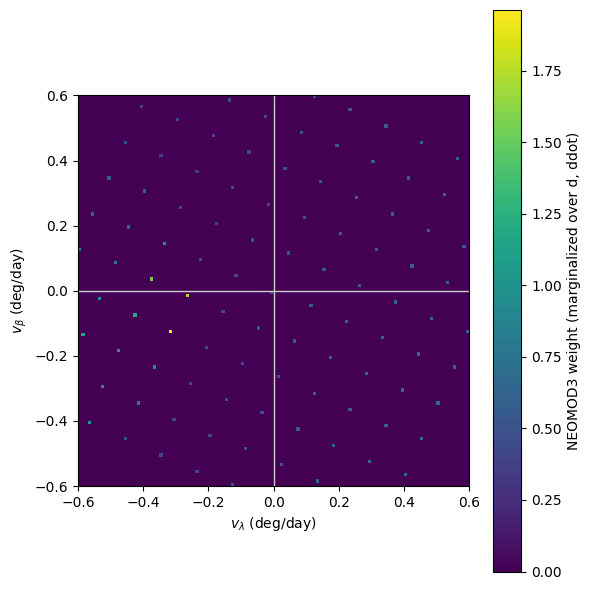

In [29]:
# CELL ABOVE TAKES 9 MINS TO RUN DO NOT RUN AGAIN ON ACCIDENT OR ITS AN UNSKIPPABLE CUTSCENE!!!
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
extent = [vlam_edges[0], vlam_edges[-1], vbet_edges[0], vbet_edges[-1]]
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(H, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
#plt.title("v_lambda–v_beta distribution (integrated over d [0.05,5] AU, ddot [−60,60] km/s)\n"
#          f"{obstime_str}")
plt.tight_layout()
plt.show()